In [1]:
!pip install prophet xgboost lightgbm -q

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from prophet import Prophet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving GlobalWeatherRepository.csv to GlobalWeatherRepository.csv


In [4]:
df = pd.read_csv("GlobalWeatherRepository.csv")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,5/16/24 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,4:50 AM,6:50 PM,12:12 PM,1:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,5/16/24 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,5:21 AM,7:54 PM,12:58 PM,2:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,5/16/24 9:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,5:40 AM,7:50 PM,1:15 PM,2:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,5/16/24 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,6:31 AM,9:11 PM,2:12 PM,3:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,5/16/24 9:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,6:12 AM,5:55 PM,1:17 PM,12:38 AM,Waxing Gibbous,55


Data Cleaning

Missing Values

In [5]:
print(df.isnull().sum())

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [6]:
df.fillna(method="ffill", inplace=True)

Remove Duplicates

In [7]:
df.drop_duplicates(inplace=True)

print(df.shape)

(153581, 41)


In [8]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

Remove Outliers




In [9]:
columns = [
    "temperature_celsius",
    "humidity",
    "wind_kph",
    "precip_mm"
]

Q1 = df[columns].quantile(0.25)
Q3 = df[columns].quantile(0.75)

IQR = Q3 - Q1

df = df[
    ~((df[columns] < (Q1 - 1.5 * IQR)) |
      (df[columns] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print(df.shape)

(118448, 41)


Normalize

In [10]:
scaler = StandardScaler()

df[columns] = scaler.fit_transform(df[columns])

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,0.548668,79.8,Partly Cloudy,...,8.4,26.6,1,1,4:50 AM,6:50 PM,12:12 PM,1:11 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,0.145022,73.4,Sunny,...,10.4,18.4,1,1,5:40 AM,7:50 PM,1:15 PM,2:14 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,0.481393,78.8,Partly cloudy,...,183.4,262.3,5,10,6:12 AM,5:55 PM,1:17 PM,12:38 AM,Waxing Gibbous,55
5,Antigua and Barbuda,Saint John's,17.12,-61.85,America/Antigua,1715849100,2024-05-16 04:45:00,0.481393,78.8,Partly cloudy,...,1.2,4.5,1,1,5:36 AM,6:32 PM,1:05 PM,1:14 AM,Waxing Gibbous,55
6,Argentina,Buenos Aires,-34.59,-58.67,America/Argentina/Buenos_Aires,1715849100,2024-05-16 05:45:00,-1.536834,46.4,Clear,...,4.0,5.3,1,1,7:43 AM,5:59 PM,2:36 PM,1:04 AM,Waxing Gibbous,55


Exploratory Data Analysis

In [11]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 118448 entries, 0 to 153580
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       118448 non-null  object        
 1   location_name                 118448 non-null  object        
 2   latitude                      118448 non-null  float64       
 3   longitude                     118448 non-null  float64       
 4   timezone                      118448 non-null  object        
 5   last_updated_epoch            118448 non-null  int64         
 6   last_updated                  118448 non-null  datetime64[ns]
 7   temperature_celsius           118448 non-null  float64       
 8   temperature_fahrenheit        118448 non-null  float64       
 9   condition_text                118448 non-null  object        
 10  wind_mph                      118448 non-null  float64       
 11  wind_kph          

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,118448.000000,118448.000000,1.184480e+05,118448,1.184480e+05,118448.00000,118448.000000,1.184480e+05,118448.000000,118448.000000,...,118448.000000,118448.000000,118448.000000,118448.000000,118448.000000,118448.000000,118448.000000,118448.000000,118448.000000,118448.000000
mean,19.896889,18.493265,1.750212e+09,2025-06-18 03:57:32.426381312,-4.799019e-18,71.07364,7.617197,1.718049e-16,168.523259,1014.668209,...,17.156337,434.726494,59.215531,15.213278,10.696401,25.287677,53.043844,1.736796,2.701785,49.959307
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-2.602010e+00,29.20000,2.200000,-1.166844e+00,1.000000,964.000000,...,3.600000,-9999.000000,0.000000,0.000000,0.000000,0.185000,-1848.150000,1.000000,1.000000,0.000000
25%,5.830000,-6.836100,1.733051e+09,2024-12-01 20:33:45,-6.174195e-01,61.10000,3.800000,-8.300909e-01,78.000000,1011.000000,...,9.900000,188.600000,39.000000,2.000000,1.150000,7.770000,10.915000,1.000000,1.000000,15.000000
50%,18.539200,20.465100,1.750237e+09,2025-06-18 08:37:30,1.786593e-01,73.90000,6.500000,-2.508758e-01,161.000000,1014.000000,...,14.700000,281.850000,56.000000,6.200000,2.650000,14.950000,21.275000,1.000000,2.000000,50.000000
75%,40.400000,46.450000,1.767079e+09,2025-12-30 14:15:00,7.056410e-01,82.40000,10.500000,6.246818e-01,257.000000,1019.000000,...,22.800000,444.000000,75.000000,17.945000,8.700000,29.230000,45.510000,2.000000,3.000000,85.000000
max,65.300000,179.220000,1.784181e+09,2026-07-16 17:45:00,2.656595e+00,113.80000,21.500000,3.008893e+00,360.000000,3006.000000,...,75.500000,33752.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000
std,24.384954,61.794383,1.977790e+07,NaN,1.000004e+00,16.05362,4.616305,1.000004e+00,104.883956,10.566998,...,9.823258,660.644226,31.707185,23.194305,23.189269,37.246776,159.608597,0.955105,2.500637,35.118107


Correlation Heatmap

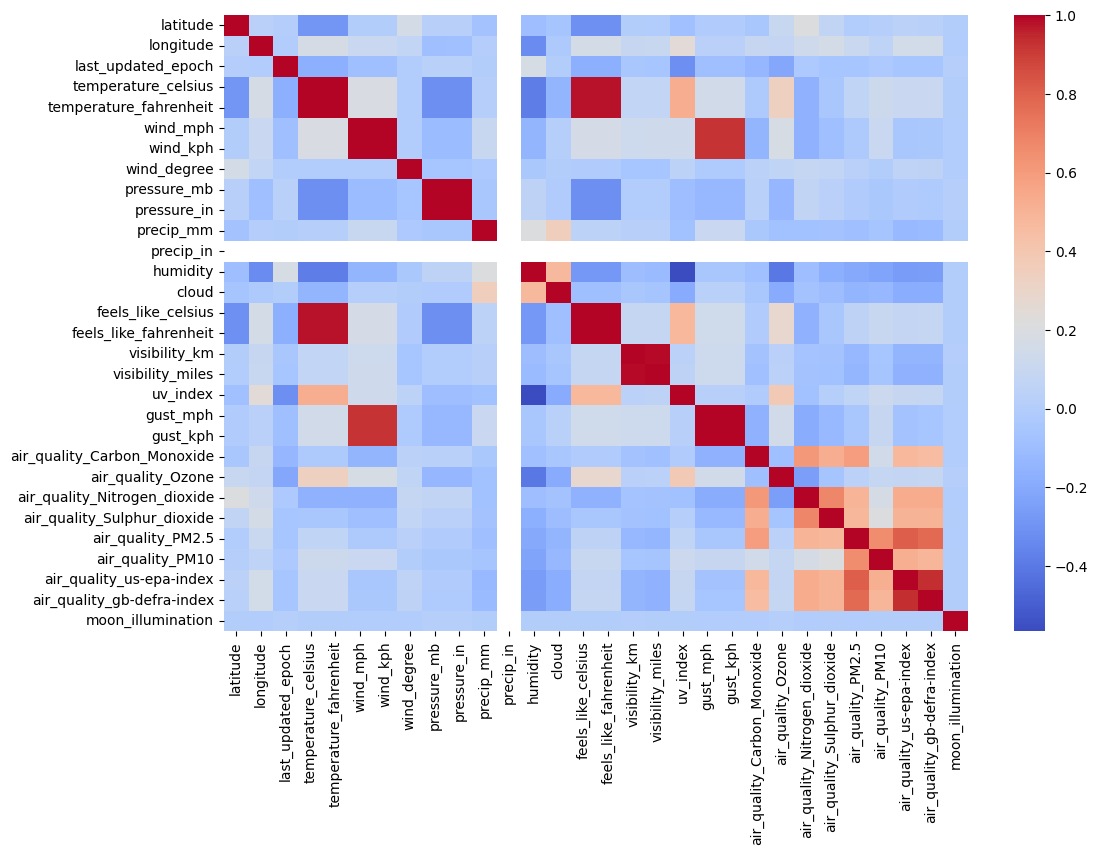

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

plt.show()

Temperature Distribution




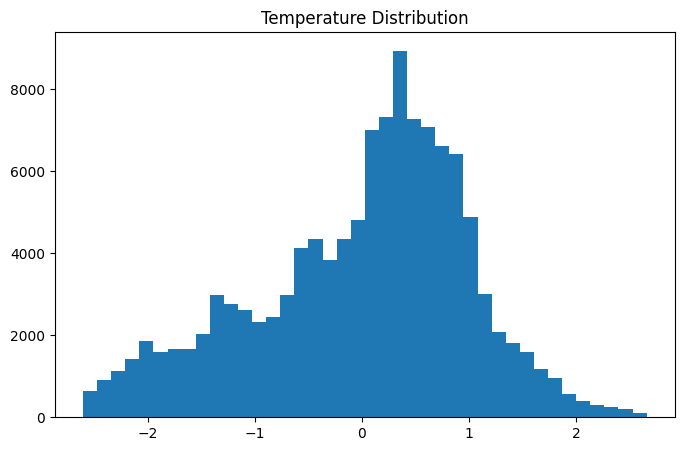

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["temperature_celsius"], bins=40)

plt.title("Temperature Distribution")

plt.show()

Precipitation Distribution

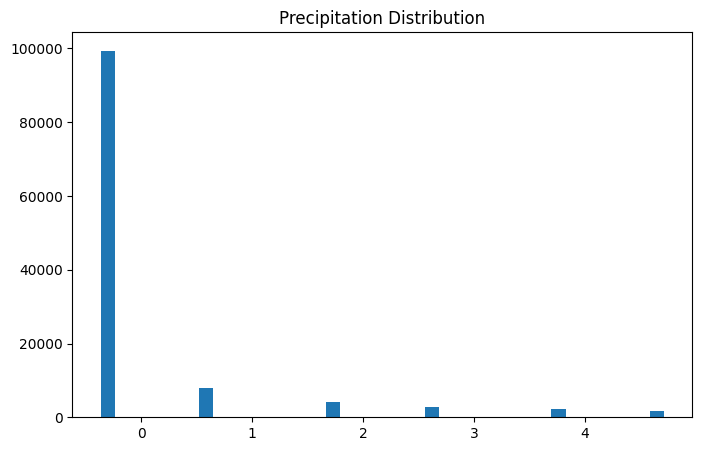

In [14]:
plt.figure(figsize=(8,5))

plt.hist(df["precip_mm"], bins=40)

plt.title("Precipitation Distribution")

plt.show()

Top 20 Hottest Countries

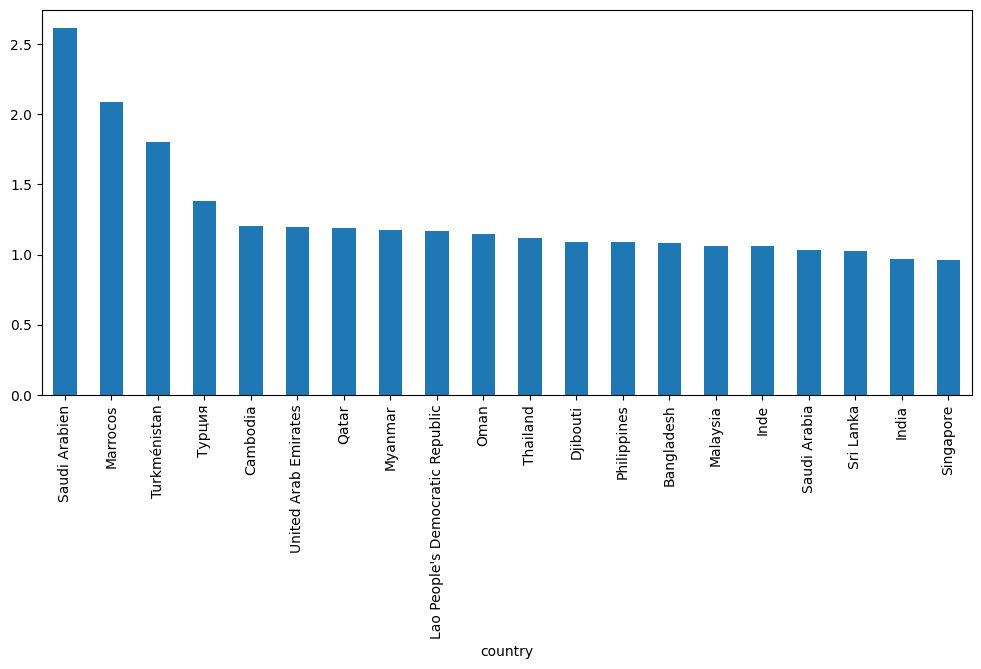

In [15]:
country = df.groupby("country")["temperature_celsius"].mean()

country.sort_values(ascending=False).head(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.show()

Temperature Time Series

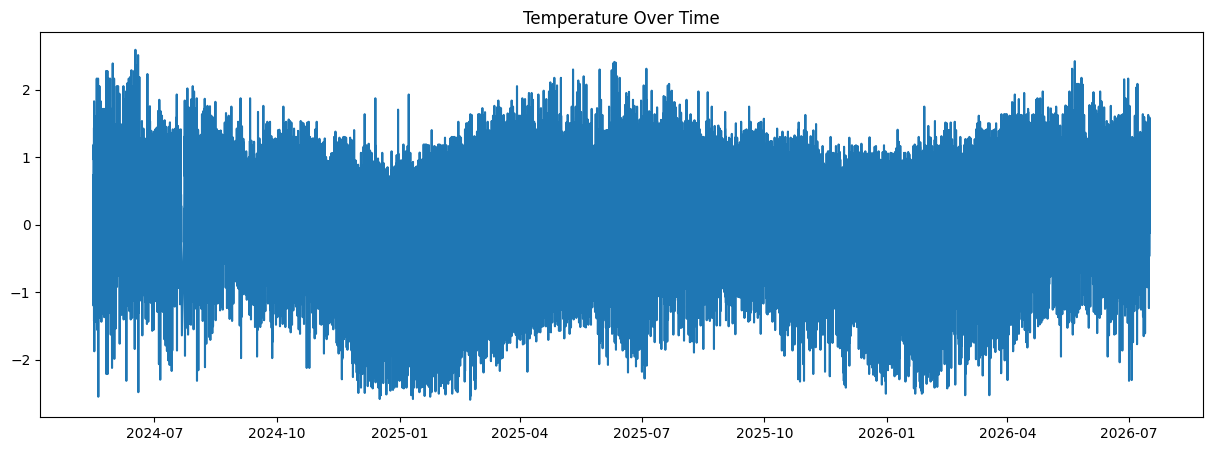

In [16]:
daily = df.groupby("last_updated")["temperature_celsius"].mean().reset_index()

plt.figure(figsize=(15,5))

plt.plot(
    daily["last_updated"],
    daily["temperature_celsius"]
)

plt.title("Temperature Over Time")

plt.show()

Precipitation Time Series

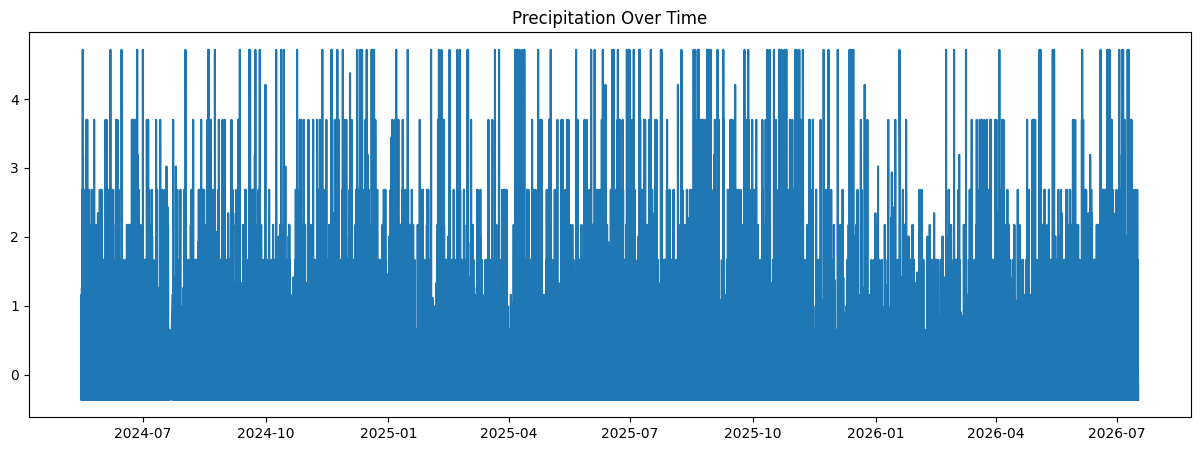

In [17]:
rain = df.groupby("last_updated")["precip_mm"].mean().reset_index()

plt.figure(figsize=(15,5))

plt.plot(
    rain["last_updated"],
    rain["precip_mm"]
)

plt.title("Precipitation Over Time")

plt.show()

Model Building


In [18]:
df["last_updated"] = pd.to_datetime(df["last_updated"])

In [19]:
df["day"] = df["last_updated"].dt.day
df["month"] = df["last_updated"].dt.month
df["year"] = df["last_updated"].dt.year

In [20]:
X = df[["day", "month", "year"]]
y = df["temperature_celsius"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [23]:
predictions = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2 Score:", r2_score(y_test, predictions))

MAE: 0.7918097460730705
RMSE: 0.9924425854418869
R2 Score: 0.027332726647379957


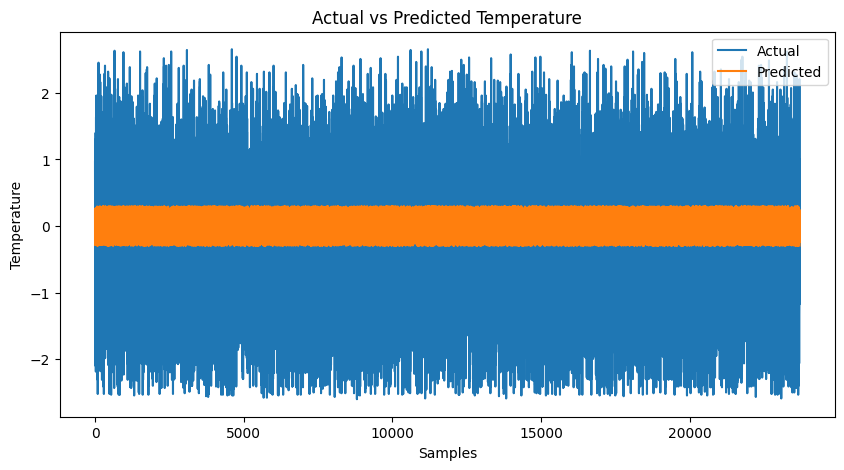

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.legend()
plt.show()

Advanced Assessment

Anomaly Detection



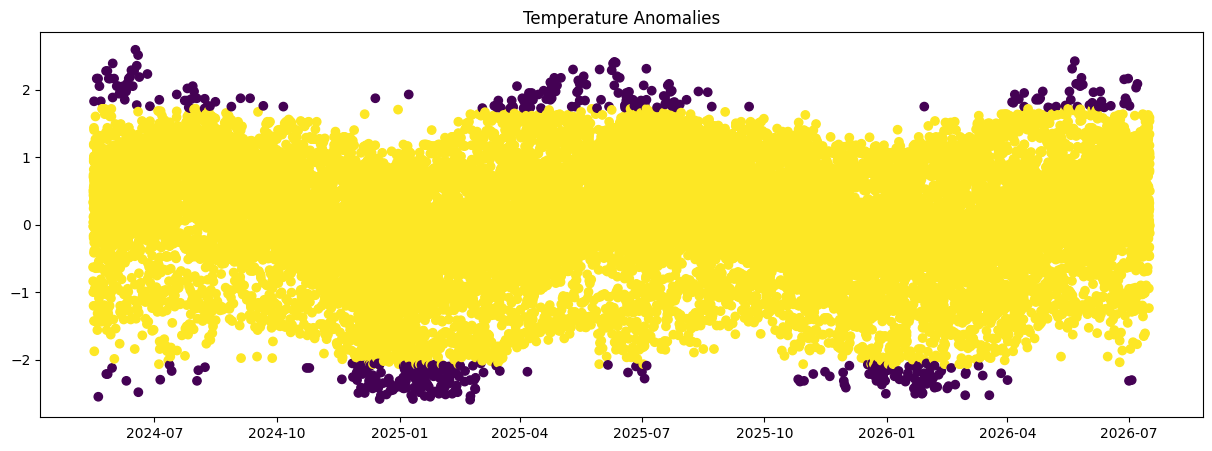

In [26]:
iso = IsolationForest(contamination=0.02)

daily["anomaly"] = iso.fit_predict(
    daily[["temperature_celsius"]]
)

plt.figure(figsize=(15,5))

plt.scatter(
    daily["last_updated"],
    daily["temperature_celsius"],
    c=daily["anomaly"]
)

plt.title("Temperature Anomalies")

plt.show()

Forecasting


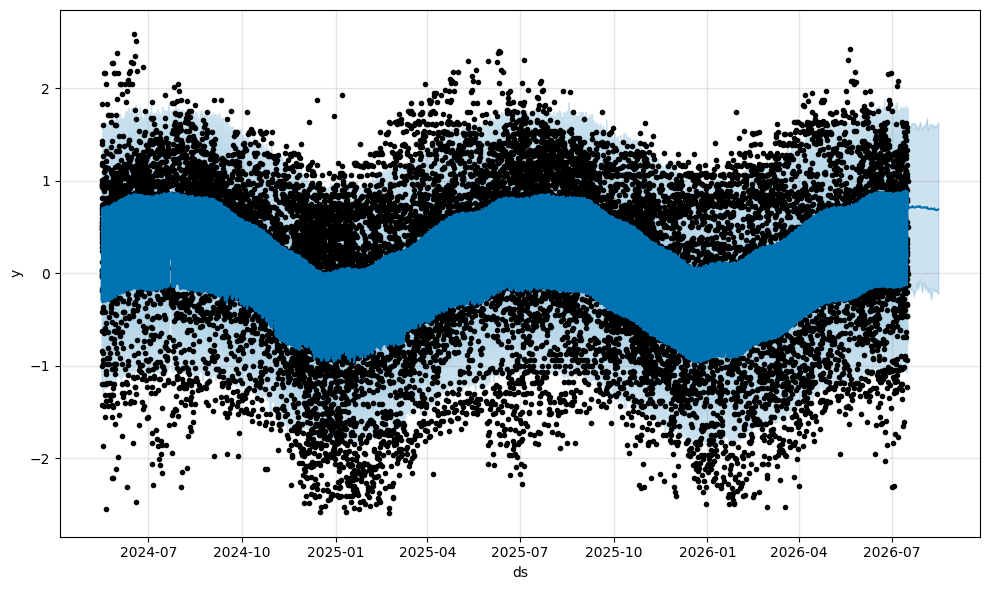

In [27]:
forecast_df = daily.rename(
    columns={
        "last_updated":"ds",
        "temperature_celsius":"y"
    }
)

model = Prophet()

model.fit(forecast_df)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

model.plot(forecast)

plt.show()

Random Forest

In [28]:
daily["day"] = daily["last_updated"].dt.day
daily["month"] = daily["last_updated"].dt.month
daily["year"] = daily["last_updated"].dt.year

X = daily[["day","month","year"]]
y = daily["temperature_celsius"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

XGBoost

In [29]:
xgb = XGBRegressor()

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

LightGBM

In [30]:
lgb = LGBMRegressor()

lgb.fit(X_train,y_train)

pred_lgb = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 49
[LightGBM] [Info] Number of data points in the train set: 18561, number of used features: 3
[LightGBM] [Info] Start training from score 0.078446


Ensemble




In [31]:
ensemble = (
    pred +
    pred_xgb +
    pred_lgb
)/3

Model Evaluation

In [32]:
print("Random Forest MAE:", mean_absolute_error(y_test,pred))

print("XGBoost MAE:", mean_absolute_error(y_test,pred_xgb))

print("LightGBM MAE:", mean_absolute_error(y_test,pred_lgb))

print("Ensemble MAE:", mean_absolute_error(y_test,ensemble))

Random Forest MAE: 0.6069472603683597
XGBoost MAE: 0.6042635805273646
LightGBM MAE: 0.5959314009303006
Ensemble MAE: 0.6019548006189761


Feature Importance

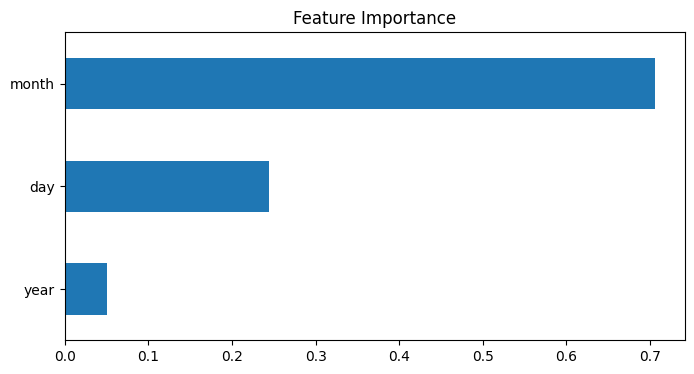

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,4)
)

plt.title("Feature Importance")

plt.show()

Climate Analysis




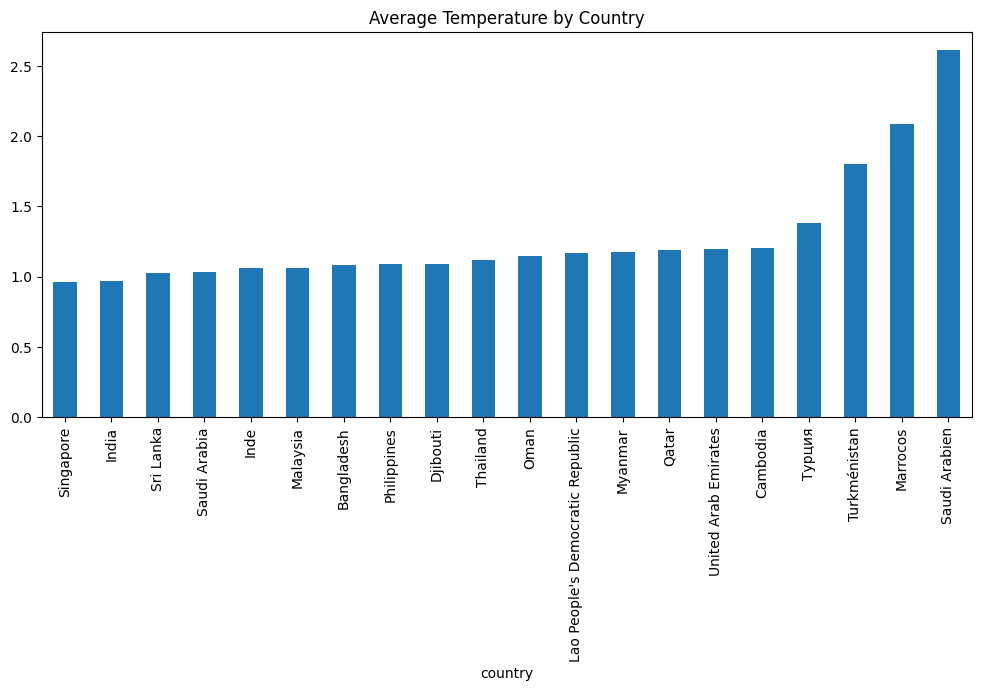

In [34]:
country = df.groupby("country")["temperature_celsius"].mean()

country.sort_values().tail(20).plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Average Temperature by Country")

plt.show()

Environmental Impact

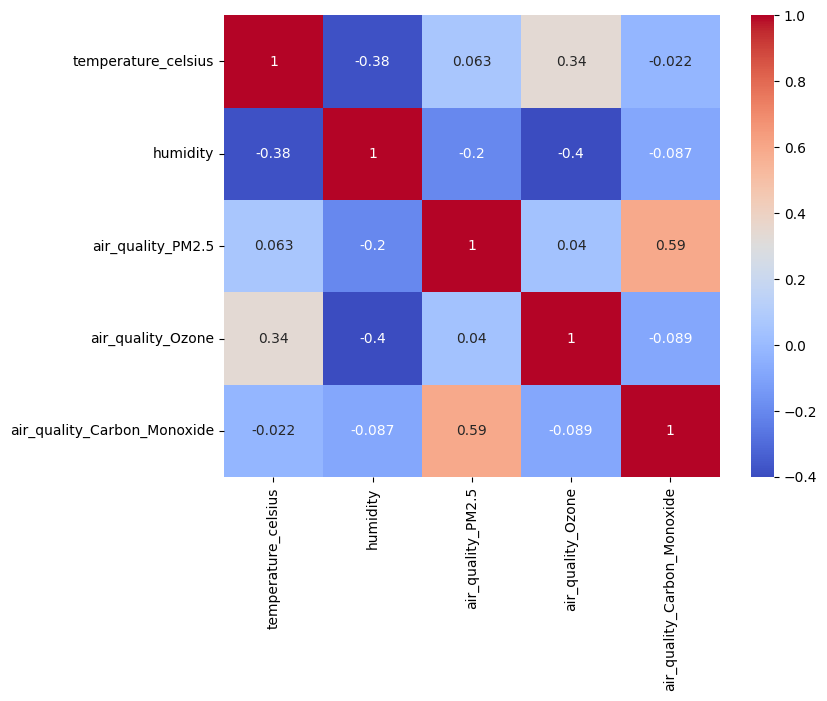

In [35]:
columns = [
    "temperature_celsius",
    "humidity",
    "air_quality_PM2.5",
    "air_quality_Ozone",
    "air_quality_Carbon_Monoxide"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Spatial Analysis

In [37]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv("GlobalWeatherRepository.csv")

# Create map
fig = px.scatter_geo(
    df.sample(min(5000, len(df))),
    lat="latitude",
    lon="longitude",
    color="temperature_celsius",
    hover_name="country",
    title="Global Weather Distribution"
)

fig.show()